In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import re
from pathlib import Path


In [2]:
base_dir = Path("/media/ubuntu/sda/Monkey/agumentation")

monkeyF_files = sorted(glob.glob(str(base_dir / "monkeyF" / "fid_comparison_*.txt")))
monkeyN_files = sorted(glob.glob(str(base_dir / "monkeyN" / "fid_comparison_*.txt")))

print(f"MonkeyF files: {len(monkeyF_files)}")
print(f"MonkeyN files: {len(monkeyN_files)}")


MonkeyF files: 5
MonkeyN files: 5


In [3]:
def extract_fid_values(file_path):
    with open(file_path, 'r') as f:
        content = f.read()
    
    original_match = re.search(r'Original Method FID: ([\d.]+)', content)
    retrieval_match = re.search(r'Retrieval-Augmented Method FID: ([\d.]+)', content)
    
    original_fid = float(original_match.group(1)) if original_match else None
    retrieval_fid = float(retrieval_match.group(1)) if retrieval_match else None
    
    return original_fid, retrieval_fid

monkeyF_data = []
for file_path in monkeyF_files:
    original, retrieval = extract_fid_values(file_path)
    monkeyF_data.append([original, retrieval])

monkeyN_data = []
for file_path in monkeyN_files:
    original, retrieval = extract_fid_values(file_path)
    monkeyN_data.append([original, retrieval])

print("MonkeyF data shape:", np.array(monkeyF_data).shape)
print("MonkeyN data shape:", np.array(monkeyN_data).shape)


MonkeyF data shape: (5, 2)
MonkeyN data shape: (5, 2)


In [4]:
matrix = np.zeros((2, 2, 5))

for run_idx in range(5):
    matrix[0, 0, run_idx] = monkeyF_data[run_idx][0]
    matrix[0, 1, run_idx] = monkeyF_data[run_idx][1]
    matrix[1, 0, run_idx] = monkeyN_data[run_idx][0]
    matrix[1, 1, run_idx] = monkeyN_data[run_idx][1]

print("Matrix shape:", matrix.shape)
print("\nMatrix structure:")
print("Dimension 0: Monkey (0=MonkeyF, 1=MonkeyN)")
print("Dimension 1: Method (0=Original, 1=Retrieval-Augmented)")
print("Dimension 2: Run (0-4)")
print("\nMatrix values:")
print(matrix)


Matrix shape: (2, 2, 5)

Matrix structure:
Dimension 0: Monkey (0=MonkeyF, 1=MonkeyN)
Dimension 1: Method (0=Original, 1=Retrieval-Augmented)
Dimension 2: Run (0-4)

Matrix values:
[[[61.0376 61.0376 61.0376 61.0376 61.0376]
  [47.5258 47.5258 47.5258 47.5258 47.5258]]

 [[57.0582 57.0623 57.0623 57.0623 57.0623]
  [48.6927 48.6576 48.6576 48.6576 48.6576]]]


In [5]:
df_data = []
for monkey_idx, monkey_name in enumerate(['MonkeyF', 'MonkeyN']):
    for method_idx, method_name in enumerate(['Original', 'Retrieval-Augmented']):
        for run_idx in range(5):
            df_data.append({
                'Monkey': monkey_name,
                'Method': method_name,
                'Run': f'Run_{run_idx+1}',
                'FID': matrix[monkey_idx, method_idx, run_idx]
            })

df = pd.DataFrame(df_data)

pivot_df = df.pivot_table(
    index=['Monkey', 'Method'],
    columns='Run',
    values='FID'
)

pivot_df.to_csv(base_dir / "fid_results_matrix.csv")
print("Saved to:", base_dir / "fid_results_matrix.csv")
print("\nDataFrame:")
print(pivot_df)


Saved to: /media/ubuntu/sda/Monkey/agumentation/fid_results_matrix.csv

DataFrame:
Run                            Run_1    Run_2    Run_3    Run_4    Run_5
Monkey  Method                                                          
MonkeyF Original             61.0376  61.0376  61.0376  61.0376  61.0376
        Retrieval-Augmented  47.5258  47.5258  47.5258  47.5258  47.5258
MonkeyN Original             57.0582  57.0623  57.0623  57.0623  57.0623
        Retrieval-Augmented  48.6927  48.6576  48.6576  48.6576  48.6576


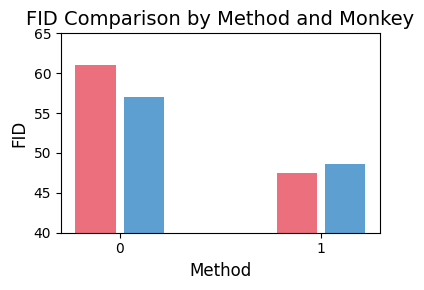

In [17]:
monkeyF_original_mean = np.mean(matrix[0, 0, :])
monkeyF_original_std = np.std(matrix[0, 0, :], ddof=1)
monkeyF_retrieval_mean = np.mean(matrix[0, 1, :])
monkeyF_retrieval_std = np.std(matrix[0, 1, :], ddof=1)

monkeyN_original_mean = np.mean(matrix[1, 0, :])
monkeyN_original_std = np.std(matrix[1, 0, :], ddof=1)
monkeyN_retrieval_mean = np.mean(matrix[1, 1, :])
monkeyN_retrieval_std = np.std(matrix[1, 1, :], ddof=1)

methods = ['Original', 'Retrieval-Augmented']
x = np.arange(len(methods))
width = 0.2

fig, ax = plt.subplots(figsize=(4, 3))

bars1 = ax.bar(x - width/2 - 0.02, [monkeyF_original_mean, monkeyF_retrieval_mean], width, 
               label='MonkeyF', color='#EC6F7E')
bars2 = ax.bar(x + width/2 + 0.02, [monkeyN_original_mean, monkeyN_retrieval_mean], width, 
               label='MonkeyN', alpha=1, color='#5E9FD1')

ax.set_xlabel('Method', fontsize=12)
ax.set_ylabel('FID', fontsize=12)
ax.set_title('FID Comparison by Method and Monkey', fontsize=14)
ax.set_xticks(x)
ax.set_ylim(40, 65)
plt.tight_layout()
plt.savefig(base_dir / "fid_comparison_barplot.pdf")
plt.show()
